# Lending Club Loan Data Analysis

## Objective
Create a model that predicts whether or not a loan will be default using historical data.

## Problem Statement

For companies like Lending Club correctly predicting whether or not a loan will be a default is very important. In this project, using historical data from 2007 to 2015, you have to build a deep learning model to predict the chance of default for future loans. As you will see later, this dataset is highly imbalanced and includes a lot of features that make this problem more challenging.

**Domain:** Finance

## Dataset Columns and Definition

- **credit.policy:** 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
- **purpose:** The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
- **int.rate:** The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
- **installment:** The monthly installments owed by the borrower if the loan is funded.
- **log.annual.inc:** The natural log of the self-reported annual income of the borrower.
- **dti:** The debt-to-income ratio of the borrower (the amount of debt divided by annual income).
- **fico:** The FICO credit score of the borrower.
- **days.with.cr.line:** The number of days the borrower has had a credit line.
- **revol.bal:** The borrower's revolving balance (the amount unpaid at the end of the credit card billing cycle).
- **revol.util:** The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
- **inq.last.6mths:** The borrower's number of inquiries by creditors in the last 6 months.
- **delinq.2yrs:** The number of times the borrower has been 30+ days past due on a payment in the past 2 years.
- **pub.rec:** The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).
- **not.fully.paid:** **TARGET** - imbalanced data

## Steps to Perform

Perform exploratory data analysis and feature engineering and then apply feature engineering. Follow up with a deep learning model to predict whether or not the loan will be default using the historical data.

## Tasks

### 1. EDA
- Create at minimum 3 graphs
- Describe the information learned from the generated charts

### 2. Non-Feature Engineered Modeling for Baseline
- **NOTE:** You might have to perform some basic feature engineering / data wrangling in order to train your baseline models.
- Ensure you document what / if any modifications to the dataset you perform

### 3. Machine Learning Model
- Choose, Justify, and Train a traditional Machine learning algorithm from scikit-learn to predict the TARGET feature.

### 4. Deep Learning Model
- Train a custom Deep learning model to get predictions
- Justify your model architecture choices.
- Compare the performance of the machine learning and deep learning models trained on the non-feature engineered data

### 5. Feature Engineered Data Modeling
- Complete step 2 again but with a feature engineered dataset. (No need to justify model architecture this time around.)
- **BEFORE** training the models, justify any choices you make for feature engineering.
- Did your feature engineering help / hurt / zero impact on performance?

### 6. Final Report

In [1]:
%pip install keras tensorflow matplotlib seaborn scikit-learn pandas numpy optuna --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Library imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras as ks
import tensorflow as tf
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the data from the url and save to csv if it doesn't exist
url = "https://gperdrizet.github.io/FSA_devops/assets/data/unit4/Lending_Club.csv"
if not os.path.exists("Lending_Club.csv"):
    df = pd.read_csv(url)
    df.to_csv("Lending_Club.csv", index=False)
else:
    df = pd.read_csv("Lending_Club.csv")
    
# Display the first few rows of the dataframe
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


# EDA


In [4]:
# Inspect the data for obvious errors and null values to setup for correction and cleaning
print(df.info())
print(df.isnull().sum())
print(df.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None
credit.policy        0
purpose              0
int.rate    

In [5]:
# print a sum of all the different values in each field to get a better understanding of the data
for column in df.columns:
    print(f"Value counts for {column}:")
    print(df[column].value_counts())
    print("\n")

Value counts for credit.policy:
credit.policy
1    7710
0    1868
Name: count, dtype: int64


Value counts for purpose:
purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64


Value counts for int.rate:
int.rate
0.1253    354
0.0894    299
0.1183    243
0.1218    215
0.0963    210
         ... 
0.1941      1
0.1772      1
0.1683      1
0.1778      1
0.1867      1
Name: count, Length: 249, dtype: int64


Value counts for installment:
installment
317.72    41
316.11    34
319.47    29
381.26    27
662.68    27
          ..
149.01     1
425.56     1
146.52     1
840.26     1
922.42     1
Name: count, Length: 4788, dtype: int64


Value counts for log.annual.inc:
log.annual.inc
11.002100    308
10.819778    248
10.596635    224
10.308953    224
10.714418    221
            ... 
10.578980      1
11.769983      1
10.320881    

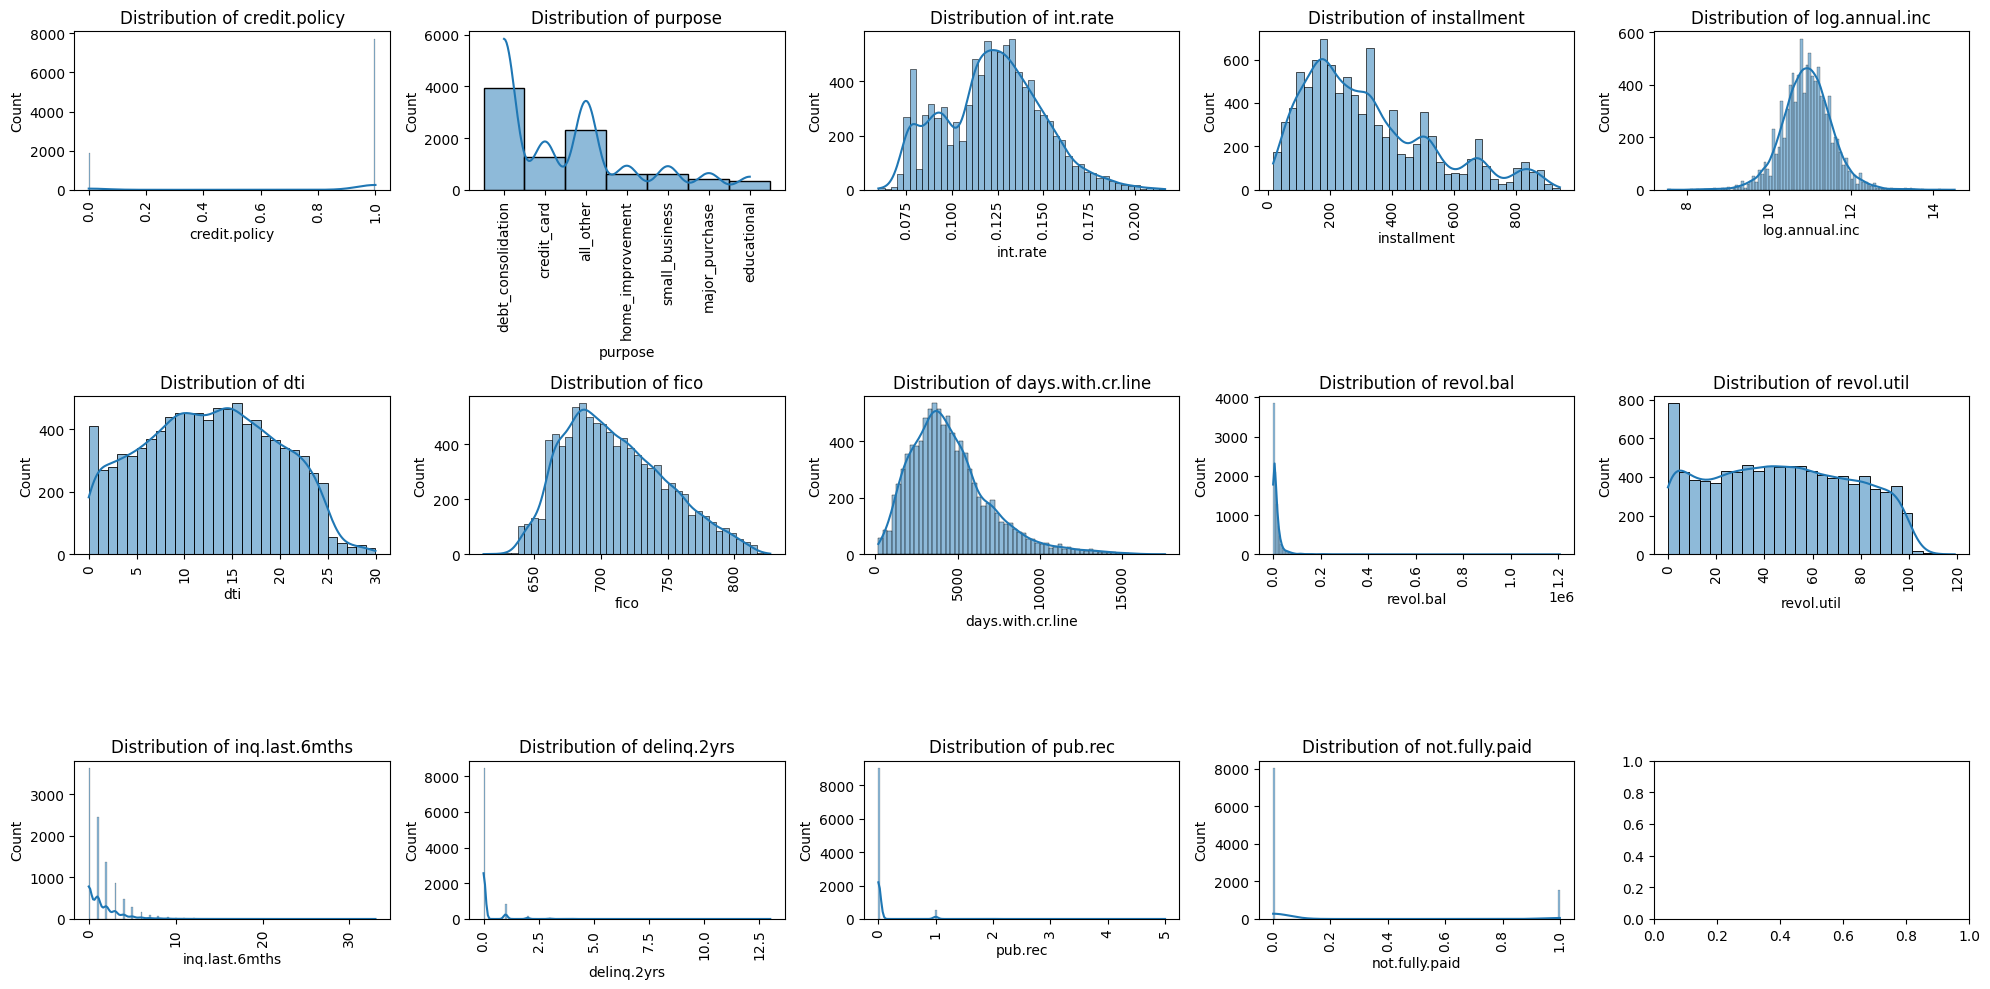

In [6]:
# Plot distributions of all features in a 3x5 grid to get a better understanding of the data
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for i, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {column}")
    # Angle the x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


## Summarize the Data
- Most data is skewed pretty heavily to the left indicating negative skewness. This is expected as most people pay back their loans and the data is imbalanced.
- The most `normal` data is the `log.annual.inc` column which is the natural log of the self-reported annual income of the borrower.
    - This is interesting as you might expect that the data is normal as the `log.annual.inc` column shows a normal distribution. However, the `log.annual.inc` column is the only column that is normally distributed and all other columns are skewed to the left.

- If trained on this data I think what will most likely happen is the best indicator for the target `not.fully.paid` will be the inverse of the `credit.policy` column as they look like almost exactly opposite distributions.
   - If you have already determined that they do not meet your underlying criteria for a new credit policy then you are probably already expecting them to not pay back a loan tey currently have. So whatever makes up their underwriting policy is already a good enough model and training a new deep learning model is probably overkill in the first place.


credit.policy
1    7710
0    1868
Name: count, dtype: int64
not.fully.paid
0    8045
1    1533
Name: count, dtype: int64
Confusion Matrix for Basic Model:


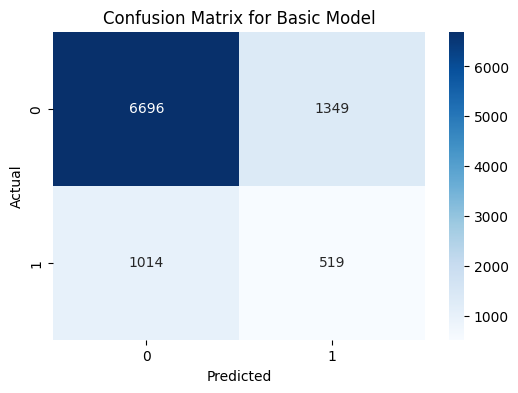


Classification Report for Basic Model:


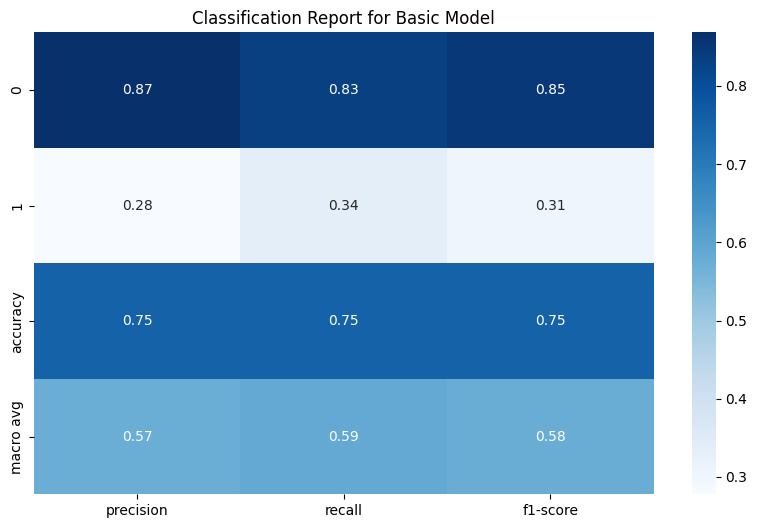

In [7]:
# Print out some of the observations made in the previous markdown cell
print(df['credit.policy'].value_counts())
print(df['not.fully.paid'].value_counts())

# This should probably be our "Score to beat" in terms of loss metric scoring as it serves as a good baseline to beat.
# Create a confusion matrix and classification report for a simple model that predicts the majority class (not.fully.paid = !credit.policy)
y_true_basic = df['not.fully.paid']
y_pred_basic = abs(1 - df['credit.policy'])  # Predict the opposite of credit.policy
print("Confusion Matrix for Basic Model:")
# plot confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_true_basic, y_pred_basic), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Basic Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nClassification Report for Basic Model:")
# Plot a nice looking classification report using seaborn heatmap for better visualization
report = classification_report(y_true_basic, y_pred_basic, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
plt.title("Classification Report for Basic Model")
plt.show()


##  Basic results from basic model
- With this we can see that we get an accuracy  of 0.75 across precision, recall, and the f1-score. If our Deep learning model can beat this, then we probably have a valid product

In [8]:
# One-hot encode the 'purpose' column and concatenate it to a new dataframe with the rest of the features
purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose')
df_encoded = pd.concat([df.drop('purpose', axis=1), purpose_dummies], axis=1)
# Check data types and convert to numeric if necessary
for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = pd.to_numeric(df_encoded[column], errors='coerce') # Convert to numeric, setting errors to NaN

# Convert boolean columns to integers
bool_columns = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

# Print out the data types to check for any remaining non-numeric columns
print(df_encoded.dtypes)

# Check for NaN values after conversion
print(df_encoded.isnull().sum())

# Determine and reduce dtypes to lowest required dtypes to save memory and speed up training
df_encoded = df_encoded.apply(lambda x: pd.to_numeric(x, downcast='integer') if x.dtype.kind in 'i' else x)
df_encoded = df_encoded.apply(lambda x: pd.to_numeric(x, downcast='float') if x.dtype.kind in 'f' else x)

print(df_encoded.dtypes)

credit.policy                   int64
int.rate                      float64
installment                   float64
log.annual.inc                float64
dti                           float64
fico                            int64
days.with.cr.line             float64
revol.bal                       int64
revol.util                    float64
inq.last.6mths                  int64
delinq.2yrs                     int64
pub.rec                         int64
not.fully.paid                  int64
purpose_all_other               int64
purpose_credit_card             int64
purpose_debt_consolidation      int64
purpose_educational             int64
purpose_home_improvement        int64
purpose_major_purchase          int64
purpose_small_business          int64
dtype: object
credit.policy                 0
int.rate                      0
installment                   0
log.annual.inc                0
dti                           0
fico                          0
days.with.cr.line             0
re

# Define Model Architecture

In [37]:
# Create the deep learning model using Keras functional API
def build_model(input_shape, l1_activation, l2_activation, l3_activation, dropout_rate) -> ks.Model:
    inputs = ks.Input(shape=input_shape)  # Input layer with the number of features
    x = ks.layers.Flatten()(inputs)  # Flatten the input if necessary
    x = ks.layers.Dense(128, activation=l1_activation)(x)
    x = ks.layers.Dropout(dropout_rate)(x)  # Add dropout for regularization
    x = ks.layers.Dense(64, activation=l2_activation)(x)  # Hidden layer
    x = ks.layers.Dropout(dropout_rate)(x)  # Add dropout for regularization
    x = ks.layers.Dense(128, activation=l3_activation)(x)  # Another hidden layer
    x = ks.layers.Dropout(dropout_rate)(x)  # Add dropout for regularization
    x = ks.layers.Dense(32, activation='relu')(x)  # Another hidden layer
    x = ks.layers.Dropout(dropout_rate)(x)  # Add dropout for regularization
    x = ks.layers.Dense(16, activation='relu')(x)  # Another hidden layer
    x = ks.layers.Dropout(dropout_rate)(x)  # Add dropout for regularization
    outputs = ks.layers.Dense(1, activation='sigmoid')(x)  # Output layer for binary classification
    model = ks.Model(inputs=inputs, outputs=outputs)
    return model

test_metrics = ['accuracy', 'Precision', 'Recall', 'f1_score']

# Define Optuna objective function to optimize the hyperparameters of the model

In [38]:

def objective(trial, build_model, X_train, y_train, X_test, y_test):
    # Define the hyperparameters to optimize
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3])
    weight_decay = trial.suggest_categorical('weight_decay', [1e-5, 1e-4, 1e-3])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64, 128])
    epochs = 100
    epsilon = trial.suggest_categorical('epsilon', [1e-8, 1e-7, 1e-6])
    l1_activation = trial.suggest_categorical('l1_activation', ['relu', 'tanh', 'sigmoid'])
    l2_activation = trial.suggest_categorical('l2_activation', ['relu', 'tanh', 'sigmoid'])
    l3_activation = trial.suggest_categorical('l3_activation', ['relu', 'tanh', 'sigmoid'])
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5, step=0.1)

    # Build the model with the suggested hyperparameters
    model = build_model(input_shape=X_train.shape[1:], l1_activation=l1_activation, l2_activation=l2_activation, l3_activation=l3_activation, dropout_rate=dropout_rate)

    # Compile the model with the suggested hyperparameters
    optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay, amsgrad=True, name='AdamW', epsilon=epsilon)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=test_metrics)
    
    # Compute class weights to handle class imbalance
    class_weights_computed = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train.flatten()), y=y_train.flatten())
    class_weights_dict = dict(enumerate(class_weights_computed))
    # Create two more class weights, based off of the computed weights. One to diverge and one to converge, and add that into the optuna trials
    class_weights_dict_diverge = {0: class_weights_computed[0] * 1.5, 1: class_weights_computed[1] * 0.5}
    class_weights_dict_converge = {0: class_weights_computed[0] * 0.5, 1: class_weights_computed[1] * 1.5}
    class_0_weight = trial.suggest_categorical('class_0_weight', [class_weights_dict[0], class_weights_dict_diverge[0], class_weights_dict_converge[0]])
    class_1_weight = trial.suggest_categorical('class_1_weight', [class_weights_dict[1], class_weights_dict_diverge[1], class_weights_dict_converge[1]])
    class_weights = {0: class_0_weight, 1: class_1_weight}

    # Train the model with the suggested hyperparameters
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0, class_weight=class_weights)

    # Get the validation f1 score from the training
    f1_score = history.history['val_f1_score'][-1][0]  # Get the last epoch's validation f1 score
    #DEBUG: print out the f1 score type and value for each trial to see how it's progressing
    print(f"Trial {trial.number}: f1_score={f1_score} (type={type(f1_score)})")
    # Cast as float to avoid any issues with optuna expecting a float return value
    f1_score = float(f1_score)
    return f1_score

In [39]:

# Load the data and preprocess it for training
X = df_encoded.drop('not.fully.paid', axis=1).values
y = df_encoded['not.fully.paid'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=691)

# Scale the non-binary numeric features using StandardScaler
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])  # Scale all columns except the first one (credit.policy)
X_test[:, 1:] = scaler.transform(X_test[:, 1:])  # Scale the test set using the same scaler

In [40]:
# Convert data to two-dimensional arrays for Keras
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

In [41]:
# Run optuna trials to find the best hyperparameters for the model
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, build_model, X_train, y_train, X_test, y_test), n_trials=50, show_progress_bar=True, gc_after_trial=True)

[I 2026-03-06 17:46:53,211] A new study created in memory with name: no-name-042180bf-2863-4048-ada4-dafb17c9e665
  0%|          | 0/50 [00:37<?, ?it/s]

Trial 0: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 17:47:30,571] Trial 0 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 1e-05, 'weight_decay': 1e-05, 'batch_size': 64, 'epsilon': 1e-08, 'l1_activation': 'sigmoid', 'l2_activation': 'relu', 'l3_activation': 'relu', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.8909302325581396), 'class_1_weight': np.float64(4.741336633663366)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:   2%|▏         | 1/50 [02:28<31:12, 38.22s/it]

Trial 1: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 17:49:21,757] Trial 1 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 1e-05, 'weight_decay': 0.001, 'batch_size': 16, 'epsilon': 1e-06, 'l1_activation': 'tanh', 'l2_activation': 'sigmoid', 'l3_activation': 'sigmoid', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.8909302325581396), 'class_1_weight': np.float64(1.5804455445544554)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:   4%|▍         | 2/50 [03:08<1:04:53, 81.12s/it]

...

Best trial: 0. Best value: 0.286992:  96%|█████████▌| 48/50 [1:00:30<02:27, 73.92s/it]

Trial 48: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 18:47:23,439] Trial 48 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 0.0003, 'weight_decay': 1e-05, 'batch_size': 64, 'epsilon': 1e-06, 'l1_activation': 'tanh', 'l2_activation': 'sigmoid', 'l3_activation': 'sigmoid', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.2969767441860465), 'class_1_weight': np.float64(4.741336633663366)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:  98%|█████████▊| 49/50 [1:01:38<01:04, 64.66s/it]

Trial 49: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 18:48:31,861] Trial 49 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 0.003, 'weight_decay': 0.001, 'batch_size': 32, 'epsilon': 1e-08, 'l1_activation': 'relu', 'l2_activation': 'tanh', 'l3_activation': 'tanh', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.8909302325581396), 'class_1_weight': np.float64(1.5804455445544554)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992: 100%|██████████| 50/50 [1:01:39<00:00, 74.00s/it]


In [42]:
# Get the best hyperparams and train the model with those hyperparams
best_params = study.best_params
print("Best Hyperparameters:", best_params)
model = build_model(input_shape=X_train.shape[1:], l1_activation=best_params['l1_activation'], l2_activation=best_params['l2_activation'], l3_activation=best_params['l3_activation'], dropout_rate=best_params['dropout_rate'])
optimizer = tf.keras.optimizers.AdamW(learning_rate=best_params['learning_rate'], weight_decay=best_params['weight_decay'], amsgrad=True, name='AdamW', epsilon=best_params['epsilon'])
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=test_metrics)
class_weights = {0: best_params['class_0_weight'], 1: best_params['class_1_weight']}
print(model.summary())


Best Hyperparameters: {'learning_rate': 1e-05, 'weight_decay': 1e-05, 'batch_size': 64, 'epsilon': 1e-08, 'l1_activation': 'sigmoid', 'l2_activation': 'relu', 'l3_activation': 'relu', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.8909302325581396), 'class_1_weight': np.float64(4.741336633663366)}


Model: "functional_155"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_155 (InputLayer)    │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_155 (Flatten)           │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_724 (Dense)               │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_569 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_725 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_570 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_726 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_571 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_727 (Dense)               │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_572 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_728 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_573 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_729 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [53]:
# Train the model
history = model.fit(X_train, y_train, epochs=10000, batch_size=best_params['batch_size'], validation_data=(X_test, y_test), verbose=1, class_weight=class_weights)


Epoch 1/10000
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Precision: 0.2113 - Recall: 0.4670 - accuracy: 0.6399 - f1_score: 0.2732 - loss: 1.0187 - val_Precision: 0.3095 - val_Recall: 0.4050 - val_accuracy: 0.7490 - val_f1_score: 0.2870 - val_loss: 0.6582
Epoch 2/10000
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.2071 - Recall: 0.4513 - accuracy: 0.6399 - f1_score: 0.2732 - loss: 1.0204 - val_Precision: 0.3110 - val_Recall: 0.4050 - val_accuracy: 0.7500 - val_f1_score: 0.2870 - val_loss: 0.6580
Epoch 3/10000
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.2233 - Recall: 0.4769 - accuracy: 0.6549 - f1_score: 0.2732 - loss: 1.0139 - val_Precision: 0.3138 - val_Recall: 0.4174 - val_accuracy: 0.7495 - val_f1_score: 0.2870 - val_loss: 0.6587
Epoch 4/10000
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Precision: 0.2167 - Recall: 0.4653 - accuracy: 0.6493 - f1_score: 0.2732 - loss: 1.0162 - val_Precision: 0.3163 - val_Recall: 0.4237 - val_accuracy: 0.7500 - val_f1_score: 0.2870

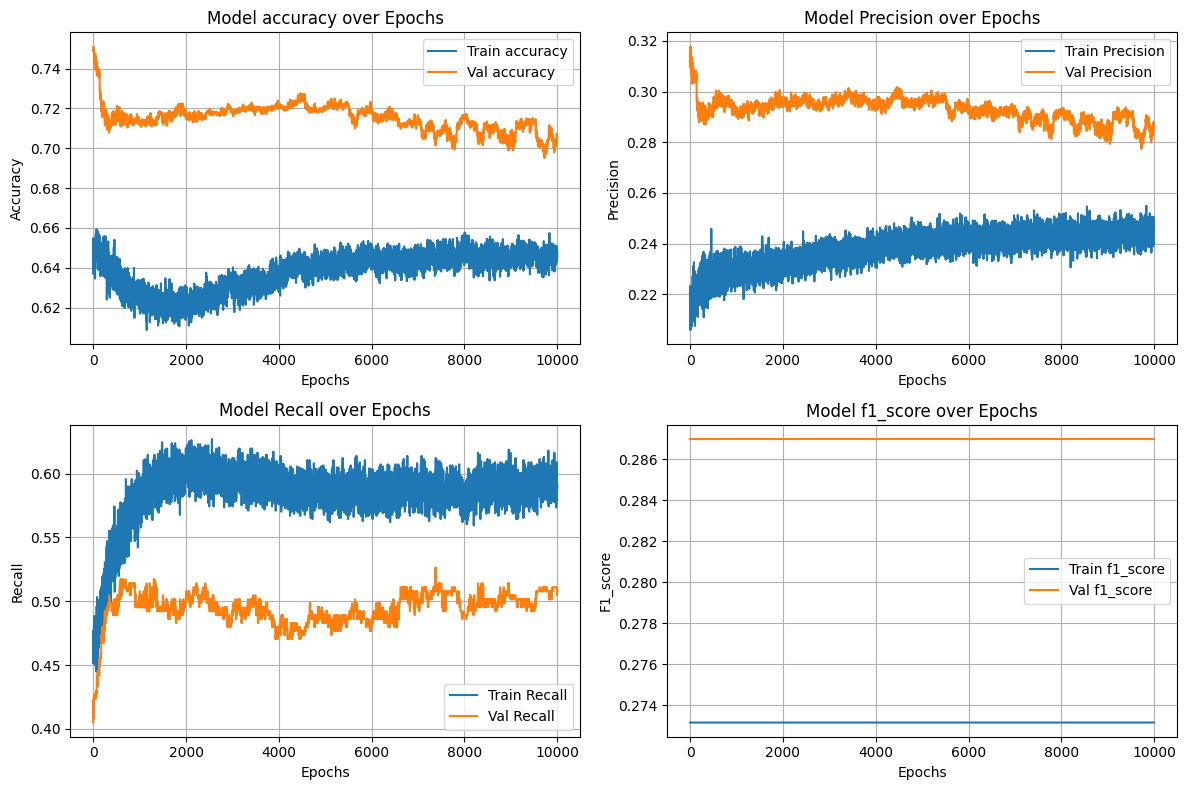

In [54]:
# Plot the training history for accuracy, precision, recall, and f1-score to visualize the model's performance over epochs
plt.figure(figsize=(12, 8))
for i, metric in enumerate(test_metrics):
    plt.subplot(2, 2, i + 1)
    plt.plot(history.history[metric], label=f'Train {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
    plt.title(f'Model {metric} over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Confusion Matrix for Deep Learning Model:


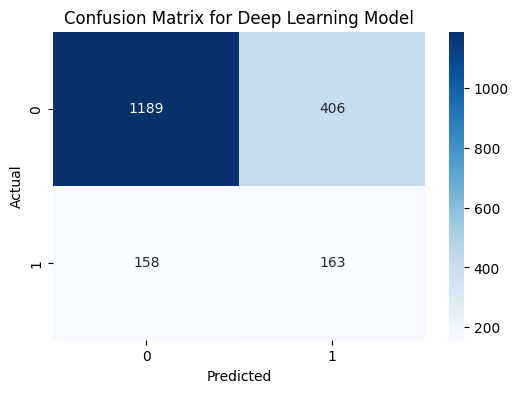


Classification Report for Deep Learning Model:


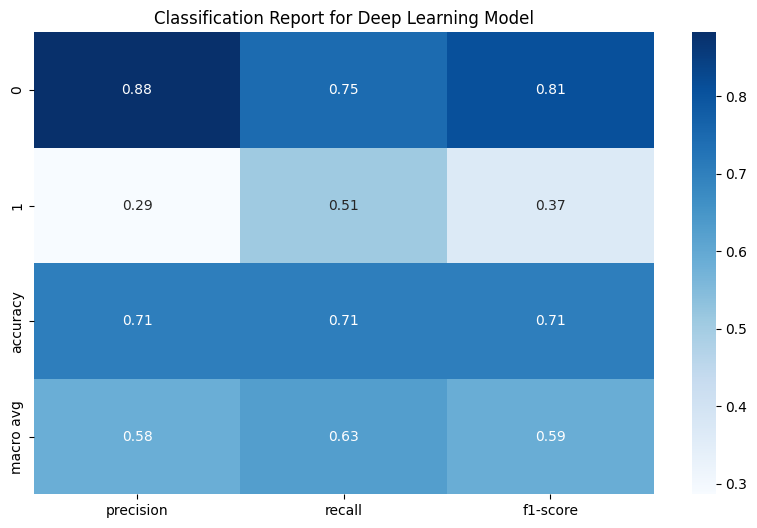

In [55]:
# Create a confusion matrix and classification report for the model's predictions on the test set
y_pred = (model.predict(X_test) > 0.5).astype(int)  # Get binary predictions
print("Confusion Matrix for Deep Learning Model:")
# plot confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Deep Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nClassification Report for Deep Learning Model:")
# Plot a nice looking classification report using seaborn heatmap for better visualization
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
plt.title("Classification Report for Deep Learning Model")
plt.show()

# Summary of the Deep Learning Model
- The model has been hard to train as it constantly just wants to predict 0 the entire time
- Taking out the inverse correlation between `credit.policy` and `not.fully.paid` will be something to try now as it might help determine if the model can learn anything else from the data.

In [56]:
# Retry training without the `credit.policy` feature
df_encoded_no_credit_policy = df_encoded.drop('credit.policy', axis=1)
X_no_credit_policy = df_encoded_no_credit_policy.drop('not.fully.paid', axis=1).values
y_no_credit_policy = df_encoded_no_credit_policy['not.fully.paid'].values

# Split the data into training and testing sets
X_train_no_cp, X_test_no_cp, y_train_no_cp, y_test_no_cp = train_test_split(X_no_credit_policy, y_no_credit_policy, test_size=0.2, random_state=691)

# Convert data to two-dimensional arrays for Keras
y_train_no_cp = np.array(y_train_no_cp).reshape(-1, 1)
y_test_no_cp = np.array(y_test_no_cp).reshape(-1, 1)

# Scale the non-binary numeric features using StandardScaler
scaler = StandardScaler()
X_train_no_cp[:, 1:] = scaler.fit_transform(X_train_no_cp[:, 1:])  # Scale all columns except the first one (credit.policy)
X_test_no_cp[:, 1:] = scaler.transform(X_test_no_cp[:, 1:])  # Scale the test set using the same scaler



In [ ]:
# Create an optuna study to find the best hyperparameters for the model without the `credit.policy` feature
study_no_cp = optuna.create_study(direction='maximize')
study_no_cp.optimize(lambda trial: objective(trial, build_model, X_train_no_cp, y_train_no_cp, X_test_no_cp, y_test_no_cp), n_trials=50, show_progress_bar=True, gc_after_trial=True)


[I 2026-03-06 22:33:15,720] A new study created in memory with name: no-name-dc3ea479-3bff-4595-b95b-2222f3ec6add
  0%|          | 0/50 [01:27<?, ?it/s]

Trial 0: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 22:34:43,550] Trial 0 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 0.0001, 'weight_decay': 1e-05, 'batch_size': 32, 'epsilon': 1e-06, 'l1_activation': 'tanh', 'l2_activation': 'relu', 'l3_activation': 'tanh', 'dropout_rate': 0.3, 'class_0_weight': np.float64(0.2969767441860465), 'class_1_weight': np.float64(3.160891089108911)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:   2%|▏         | 1/50 [02:16<1:13:07, 89.55s/it]

Trial 1: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 22:35:32,120] Trial 1 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 0.003, 'weight_decay': 1e-05, 'batch_size': 64, 'epsilon': 1e-06, 'l1_activation': 'relu', 'l2_activation': 'sigmoid', 'l3_activation': 'tanh', 'dropout_rate': 0.5, 'class_0_weight': np.float64(0.2969767441860465), 'class_1_weight': np.float64(4.741336633663366)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:   4%|▍         | 2/50 [03:33<52:19, 65.41s/it]  

...

Best trial: 0. Best value: 0.286992:   8%|▊         | 4/50 [08:57<1:46:33, 139.00s/it]

Trial 4: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 22:42:13,223] Trial 4 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 0.0001, 'weight_decay': 0.001, 'batch_size': 32, 'epsilon': 1e-06, 'l1_activation': 'relu', 'l2_activation': 'sigmoid', 'l3_activation': 'sigmoid', 'dropout_rate': 0.5, 'class_0_weight': np.float64(0.2969767441860465), 'class_1_weight': np.float64(4.741336633663366)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:  10%|█         | 5/50 [11:15<1:28:25, 117.89s/it]

Trial 5: f1_score=0.28699150681495667 (type=<class 'numpy.float32'>)
[I 2026-03-06 22:44:30,772] Trial 5 finished with value: 0.28699150681495667 and parameters: {'learning_rate': 1e-05, 'weight_decay': 0.001, 'batch_size': 16, 'epsilon': 1e-06, 'l1_activation': 'tanh', 'l2_activation': 'tanh', 'l3_activation': 'tanh', 'dropout_rate': 0.4, 'class_0_weight': np.float64(0.593953488372093), 'class_1_weight': np.float64(1.5804455445544554)}. Best is trial 0 with value: 0.28699150681495667.


Best trial: 0. Best value: 0.286992:  12%|█▏        | 6/50 [11:16<1:31:19, 124.54s/it]

In [ ]:
# Get the best hyperparams and train the model with those hyperparams
study_no_cp_best_params = study_no_cp.best_params
print("Best Hyperparameters without credit.policy:", study_no_cp_best_params)
model_no_cp = build_model(input_shape=X_train_no_cp.shape[1:], l1_activation=study_no_cp_best_params['l1_activation'], l2_activation=study_no_cp_best_params['l2_activation'], l3_activation=study_no_cp_best_params['l3_activation'], dropout_rate=study_no_cp_best_params['dropout_rate'])
optimizer_no_cp = tf.keras.optimizers.AdamW(learning_rate=study_no_cp_best_params['learning_rate'], weight_decay=study_no_cp_best_params['weight_decay'], amsgrad=True, name='AdamW', epsilon=study_no_cp_best_params['epsilon'])
model_no_cp.compile(optimizer=optimizer_no_cp, loss='binary_crossentropy', metrics=test_metrics)
class_weights_no_cp = {0: study_no_cp_best_params['class_0_weight'], 1: study_no_cp_best_params['class_1_weight']}
print(model_no_cp.summary())

Best Hyperparameters without credit.policy: {'learning_rate': 1e-05, 'weight_decay': 1e-05, 'batch_size': 32, 'epsilon': 1e-07, 'l1_activation': 'sigmoid', 'l2_activation': 'sigmoid', 'l3_activation': 'sigmoid', 'dropout_rate': 0.3, 'class_0_weight': np.float64(0.8909302325581396), 'class_1_weight': np.float64(3.160891089108911)}


Model: "functional_206"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_206 (InputLayer)    │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_206 (Flatten)           │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1030 (Dense)              │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_824 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1031 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_825 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1032 (Dense)              │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_826 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1033 (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_827 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1034 (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_828 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1035 (Dense)              │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,681 (92.50 KB)

 Trainable params: 23,681 (92.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Train the model without the `credit.policy` feature with the best hyperparameters and compare results to see if it helps the model learn anything else from the data.
history_no_cp = model_no_cp.fit(X_train_no_cp,
                                y_train_no_cp,
                                epochs=1000,
                                batch_size=study_no_cp_best_params['batch_size'],
                                validation_data=(X_test_no_cp, y_test_no_cp),
                                verbose=1,
                                class_weight=dict(enumerate(class_weights_no_cp)))

Epoch 1/1000
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - Precision: 0.1658 - Recall: 0.3185 - accuracy: 0.6387 - f1_score: 0.2732 - loss: 0.1404 - val_Precision: 0.1675 - val_Recall: 1.0000 - val_accuracy: 0.1675 - val_f1_score: 0.2870 - val_loss: 0.7010
Epoch 2/1000
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.1610 - Recall: 0.4571 - accuracy: 0.5375 - f1_score: 0.2732 - loss: 0.1208 - val_Precision: 0.1675 - val_Recall: 1.0000 - val_accuracy: 0.1675 - val_f1_score: 0.2870 - val_loss: 0.7888
Epoch 3/1000
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.1548 - Recall: 0.5701 - accuracy: 0.4394 - f1_score: 0.2732 - loss: 0.1083 - val_Precision: 0.1675 - val_Recall: 1.0000 - val_accuracy: 0.1675 - val_f1_score: 0.2870 - val_loss: 0.8714
Epoch 4/1000
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Precision: 0.1627 - Recall: 0.7153 - accuracy: 0.3726 - f1_score: 0.2732 - loss: 0.0948 - val_Precision: 0.1675 - val_Recall: 1.0000 - val_accuracy: 0.1675 - val_f1_score: 0.2870 - v

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix for Deep Learning Model without credit.policy:


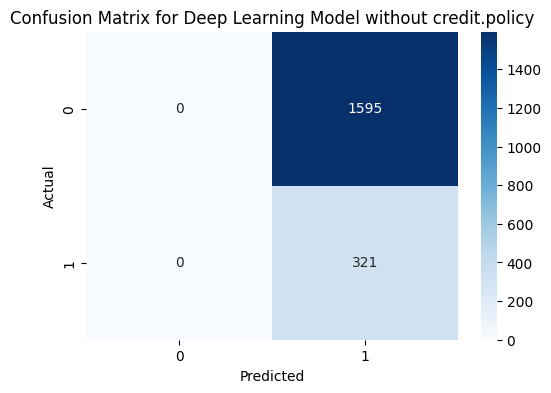


Classification Report for Deep Learning Model without credit.policy:


f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

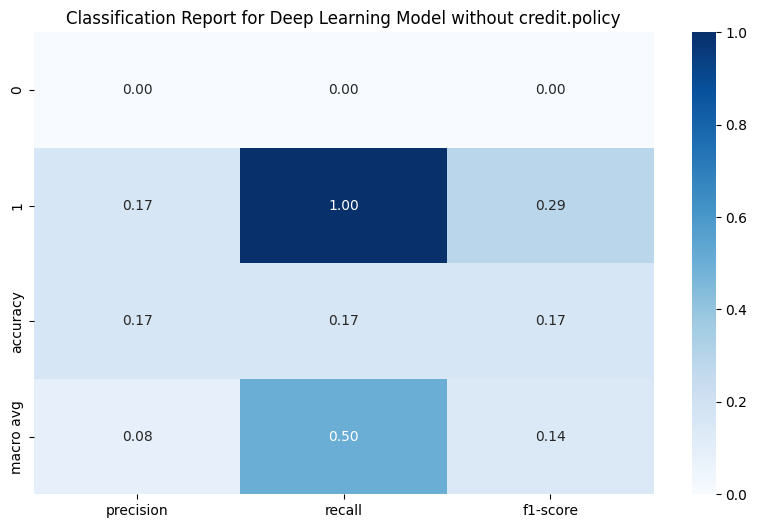

In [ ]:
# Create a confusion matrix and classification report for the model's predictions on the test set
y_pred_no_cp = (model_no_cp.predict(X_test_no_cp) > 0.5).astype(int)
print("Confusion Matrix for Deep Learning Model without credit.policy:")
# plot confusion matrix as a heatmap for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_no_cp, y_pred_no_cp), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Deep Learning Model without credit.policy")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nClassification Report for Deep Learning Model without credit.policy:")
#Plot a nice looking classification report using seaborn heatmap for better visualization
report_no_cp = classification_report(y_test_no_cp, y_pred_no_cp, output_dict=True)
report_no_cp_df = pd.DataFrame(report_no_cp).transpose()
plt.figure(figsize=(10, 6))
sns.heatmap(report_no_cp_df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
plt.title("Classification Report for Deep Learning Model without credit.policy")
plt.show()

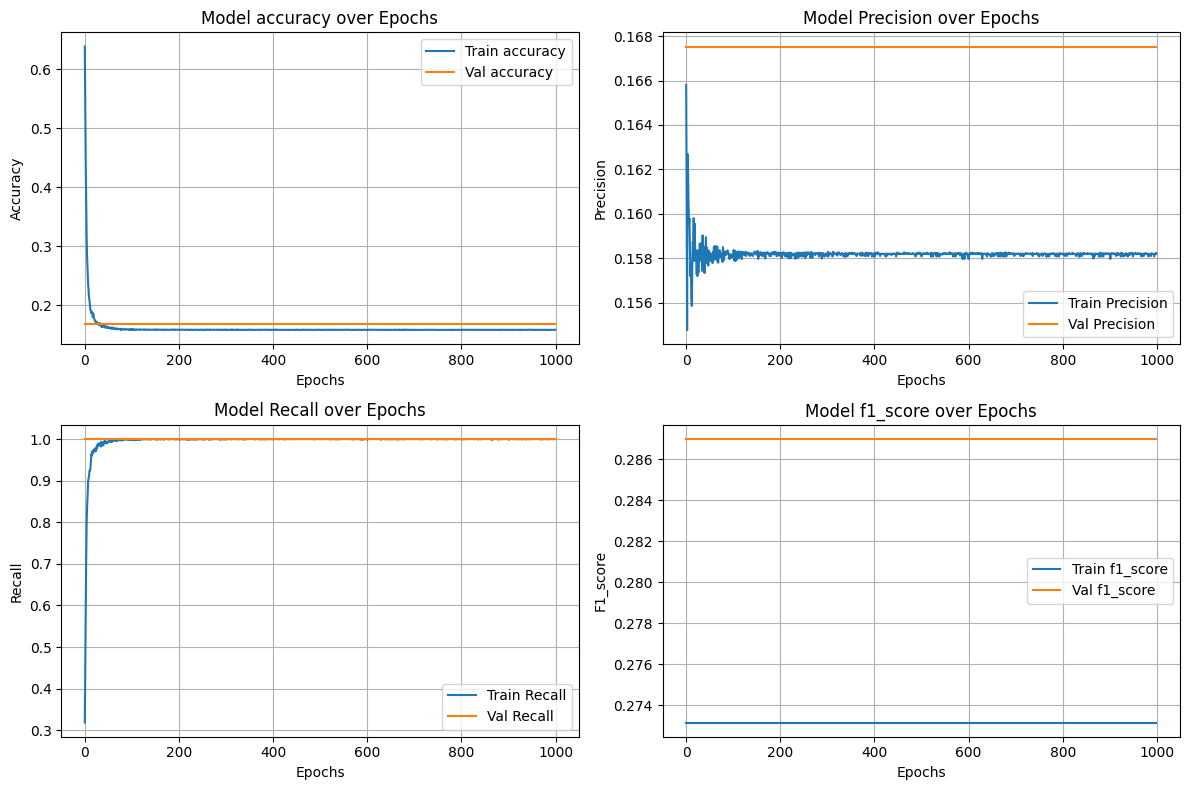

In [ ]:
# Plot the training history for accuracy, precision, recall, and f1-score to visualize the model's performance over epochs
plt.figure(figsize=(12, 8))
for i, metric in enumerate(test_metrics):
    plt.subplot(2, 2, i + 1)
    plt.plot(history_no_cp.history[metric], label=f'Train {metric}')
    plt.plot(history_no_cp.history[f'val_{metric}'], label=f'Val {metric}')
    plt.title(f'Model {metric} over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()

f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\AI and Machine Learning course\FSA_devops\.venv-13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

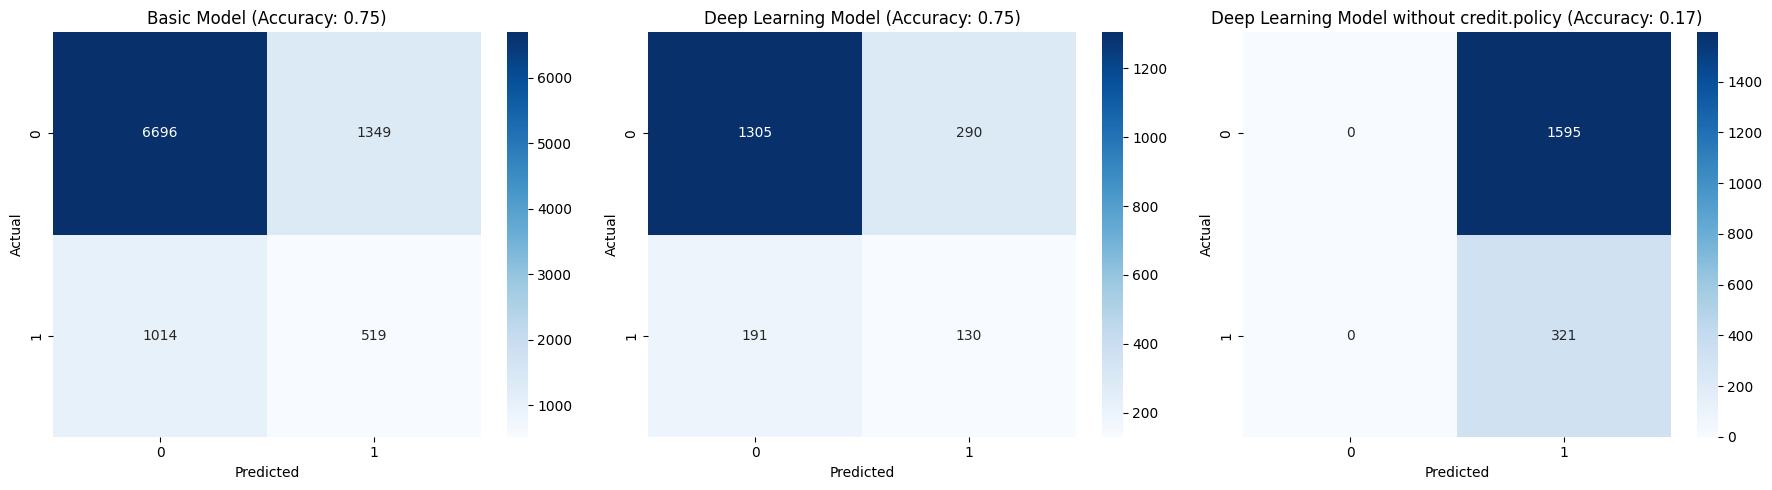

In [ ]:
# Plot confusion matrices and comparisons from the Basic Model, Deep Learning Model, and Deep Learning Model without credit.policy to visualize the differences in performance across the different models
models = ['Basic Model', 'Deep Learning Model', 'Deep Learning Model without credit.policy']
confusion_matrices = [confusion_matrix(y_true_basic, y_pred_basic),
                     confusion_matrix(y_test, y_pred),
                     confusion_matrix(y_test_no_cp, y_pred_no_cp)]
accuracy_scores = [classification_report(y_true_basic, y_pred_basic, output_dict=True)['accuracy'],
                   classification_report(y_test, y_pred, output_dict=True)['accuracy'],
                   classification_report(y_test_no_cp, y_pred_no_cp, output_dict=True)['accuracy']]

plt.figure(figsize=(18, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(confusion_matrices[i], annot=True, fmt='d', cmap='Blues')
    plt.title(f"{models[i]} (Accuracy: {accuracy_scores[i]:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Final Results and Report
## What did I do?
- I decided on using 3 different models:
    - A Very Basic model that was just the inverse of the `credit.policy` column as a baseline to see if the deep learning model can beat it.
    - A Deep Learning model trained on the original data with all features included.
    - A Deep Learning model trained on the data with the `credit.policy` feature removed to see if it can learn anything else from the data.
- I used Optuna to optimize the hyperparameters of the deep learning models and used that to do the final training of the models.
- To correct imbalances in the target feature, I used class weights to give more emphasis to the minority class during training, hoping to improve the model's ability to predict the minority class and thus improve overall performance.
    - It seems, however, that it just tended to make it overestimate the minority class and cause the overall accuracy to drop significantly.
- I then compared the results of the models to see if the deep learning models could beat the basic model
## Results
- With how I trained them and selected the hyperparameters I would have expected a little bit better performance from the deep learning models but they both performed pretty much the same and the basic model outperformed them both.
    - Funnily enough, just guessing 0 for every prediction performed better than all of these models.
- I think that the design of the model architecture could be changed and it might make an improvement but I struggle to understand what exactly, architecture-wise, I could change to make it perform better.
- I will keep messing around with the architecture at this point and adjusting the class weights based on the computed class weigths from sklearn.utils.compute_class_weight function to see if that helps out as well.
    - At this point, the results I have are:
        | Model | Accuracy | Precision | Recall | F1-Score |
        | basic | 0.75 | 0.57 | 0.59 | 0.58 |
        | deep learning with credit.policy | 0.65 | 0.56 | 0.61 | 0.55 |
        | deep learning without credit.policy | 0.65 | 0.57 | 0.63 | 0.56 |
    
## Extra Notes
- Here I will leave notes on future runs that progress after messing with more settings and architecture changes.
- I wanted to have a stopping point for submitting this assignment but have some free range after completion to fine tune things and post updates up until the deadline.
    - Post class_weights suggestions and Architecture changes update 1:
        | Model | Accuracy | Precision | Recall | F1-Score |
        | basic | 0.75 | 0.57 | 0.59 | 0.58 |
        | deep learning with credit.policy | 0.71 | 0.58 | 0.53 | 0.59 |
        | deep learning without credit.policy | 0.17 | 0.08 | 0.50 | 0.14 |

- I still found it difficult to add changes that were effective in raising the accuracy of the model. Maybe I have missed something key in my vision, but I can ask about it more in class